In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

data = pd.read_excel('jpmcdata.xlsx', sheet_name = 'AdminData_Student(Seat)')
data


,Seat Id,Student Id,School Id,Classroom Id,Course Id,Course,University,Semester,Participation Status,Pass Status,First Semester School Participation
0,Id,Student__r.Id,Student__r.AccountId,Course_Allocation__r.Id,Course_Allocation__r.Course__r.Id,Course_Name__c,University__c,Term_Name__c,Participation_Status__c,Pass_Status__c,/
1,a0LDo0000001bXGMAY,003Do00000K23aCIAR,001Do000004oQfLIAU,a0QDo000001GhTpMAK,a0RDo000000dQDXMA2,College Algebra,Howard University,Fall 2023,Participating,Passed,Y
2,a0LDo0000001bXHMAY,003Pm000007oLbWIAU,001Do000004oQfLIAU,a0QDo000001GhTpMAK,a0RDo000000dQDXMA2,College Algebra,Howard University,Fall 2023,Participating,Passed,Y
3,a0LDo0000001bXIMAY,003Do00000K2F8LIAV,001Do000004oQfLIAU,a0QDo000001GhTpMAK,a0RDo000000dQDXMA2,College Algebra,Howard University,Fall 2023,Participating,Passed,Y
4,a0LDo0000001bXJMAY,003Do00000K2nt3IAB,001Do000004oQfLIAU,a0QDo000001GhTpMAK,a0RDo000000dQDXMA2,College Algebra,Howard University,Fall 2023,Participating,Passed,Y
...,...,...,...,...,...,...,...,...,...,...,...
32894,a0LPm000006y2bNMAQ,003Pm00000O0D5wIAF,001Do000004mkX6IAI,a0QPm000009ppGDMAY,a0RPm000006h6wRMAQ,Introduction to Computers,Stanford University,Fall 2024,Participating,Did Not Pass,N
32895,a0LPm000006yRTJMA2,003Do00000E5YcGIAV,001Do000004mkNcIAI,a0QPm00000AIJeNMAX,a0RPm000006hB6QMAU,Poetry in America: The City from Whitman to Hi...,Arizona State University,Fall 2024,Participating,Did Not Pass,N
32896,a0LPm000006zPvhMAE,003Do00000LxVkoIAF,001Do000004mkREIAY,a0QPm00000DszGjMAJ,a0RPm000006h6wNMAQ,Introduction to Cloud Computing,Arizona State University,Fall 2024,Participating,Passed,N
32897,a0LPm000006zuD7MAI,003Pm00000Lvf8nIAB,001Do000004mkX6IAI,a0QPm000009ppGDMAY,a0RPm000006h6wRMAQ,Introduction to Computers,Stanford University,Fall 2024,Participating,Passed,N


In [4]:
# heatmap
#

In [5]:
# geographical map

In [6]:
# STEP 1: Install necessary package (if needed) and import
import pandas as pd
from google.colab import files

# STEP 2: Upload the file you just used
uploaded = files.upload()  # Choose 'jpmcdata.xlsx' when prompted

# STEP 3: Load the file and sheets
file_name = 'jpmcdata.xlsx'
excel_file = pd.ExcelFile(file_name)

# STEP 4: Load relevant sheets
df_student = excel_file.parse('AdminData_Student(Seat)')
df_survey_student = excel_file.parse('SurveyData_Student(Seat)')

# STEP 5: Merge student performance with survey data
merged = pd.merge(
    df_student,
    df_survey_student[['Seat Id', 'NPS']],
    on='Seat Id',
    how='left'
)

# STEP 6: Filter and rename columns
data = merged[[
    'Course', 'University', 'Semester', 'Pass Status',
    'First Semester School Participation', 'School Id', 'NPS'
]]

# Remove rows that are just headers
data = data[data['Pass Status'] != 'Pass_Status__c']

# Convert NPS column to numeric (handle NaN safely)
data['NPS'] = pd.to_numeric(data['NPS'], errors='coerce')

# STEP 7: Aggregate course success metrics
summary = data.groupby(['Course', 'University']).agg(
    total_students=('Pass Status', 'count'),
    pass_rate=('Pass Status', lambda x: (x == 'Passed').sum() / len(x)),
    avg_nps=('NPS', 'mean'),
    first_time_schools=('First Semester School Participation', lambda x: (x == 'Y').sum())
).reset_index()

# STEP 8: Sort and display top performing courses
summary_sorted = summary.sort_values(by=['pass_rate', 'avg_nps'], ascending=False)
summary_sorted.reset_index(drop=True, inplace=True)

# STEP 9: Display results
from IPython.display import display
display(summary_sorted)


Saving jpmcdata.xlsx to jpmcdata (1).xlsx


,Course,University,total_students,pass_rate,avg_nps,first_time_schools
0,Introduction to Social Work,University of Pennsylvania School of Social Po...,71,0.866667,8.777778,49
1,Raise Your Voice: Learn to Write Successfully ...,Stanford University,193,0.837438,7.526316,73
2,Searching Together for the Common Good,Stanford University,290,0.828947,9.000000,26
3,Essentials of Personal Finance,Wharton School of the University of Pennsylvania,2042,0.817805,8.467754,454
4,Data Science & Decision Making: Engineering Ap...,Cornell University,26,0.800000,6.615385,0
5,Professional Communication,Morehouse College,106,0.792308,6.662162,29
6,"Introduction to Literature: Fantastic Places, ...",Brown University,306,0.777778,7.433628,20
7,Introduction to Business Management,Cornell University,316,0.768595,7.737557,25
8,"Between Malcolm X and Martin Luther King, Jr.:...",Stanford University,103,0.767241,8.882353,26
9,College Algebra,Howard University,1413,0.746532,7.947805,374


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


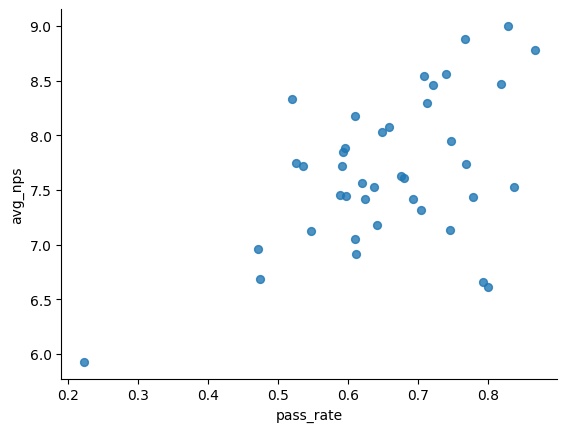

In [8]:
# @title pass_rate vs avg_nps

from matplotlib import pyplot as plt
summary_sorted.plot(kind='scatter', x='pass_rate', y='avg_nps', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

In [9]:
import plotly.express as px

# Plotting interactive scatter plot
fig = px.scatter(
    summary_sorted,
    x='pass_rate',
    y='avg_nps',
    hover_name='University',  # this shows on hover
    hover_data=['Course', 'total_students'],  # optional: show more info
    size_max=10,
    opacity=0.8,
    title='📊 Pass Rate vs Avg NPS by Course'
)

fig.update_traces(marker=dict(size=8, color='blue'))
fig.update_layout(
    xaxis_title='Pass Rate',
    yaxis_title='Average NPS',
    template='simple_white'
)
fig.show()


In [10]:
# STEP 10: Get top 5 courses by success (combined by pass rate and avg_nps)
top5_courses = summary_sorted.head(50)

# STEP 11: Count how many times each university appears in top 5
top5_concentration = top5_courses['University'].value_counts().reset_index()
top5_concentration.columns = ['University', 'Top_50_Course_Count']

# STEP 12: Display the concentration of top courses by university
print("Top 5 Course Concentration by University:")
display(top5_concentration)


Top 5 Course Concentration by University:


,University,Top_50_Course_Count
0,Howard University,6
1,Wesleyan University,6
2,Stanford University,5
3,Cornell University,5
4,Arizona State University,5
5,Brown University,4
6,Wharton School of the University of Pennsylvania,2
7,University of Pennsylvania School of Social Po...,2
8,Morehouse College,2
9,Barnard College at Columbia University,2


In [11]:
# STEP: Group and list courses for each university in the top 50
courses_by_university = top5_courses.groupby('University')['Course'].apply(list).reset_index()

# Optional: Display nicely as DataFrame
courses_by_university.columns = ['University', 'Top_50_Courses']
courses_by_university['Total Courses'] = courses_by_university['Top_50_Courses'].apply(len)

# Display the result
courses_by_university = courses_by_university.sort_values(by='Total Courses', ascending=False)
from IPython.display import display
display(courses_by_university)


,University,Top_50_Courses,Total Courses
6,Howard University,"[College Algebra, Introduction to Leadership S...",6
13,Wesleyan University,[Introduction to Sociology: Memory as Collecti...,6
3,Cornell University,[Data Science & Decision Making: Engineering A...,5
0,Arizona State University,"[Introductory Sociology, Poetry in America: Fo...",5
10,Stanford University,[Raise Your Voice: Learn to Write Successfully...,5
2,Brown University,"[Introduction to Literature: Fantastic Places,...",4
1,Barnard College at Columbia University,"[Clothing, Introduction to Microeconomics]",2
4,Georgetown University,"[Map(s) of the Modern World, International Rel...",2
12,University of Pennsylvania School of Social Po...,"[Introduction to Social Work, Social Innovation]",2
7,Morehouse College,"[Professional Communication, Social Problems]",2


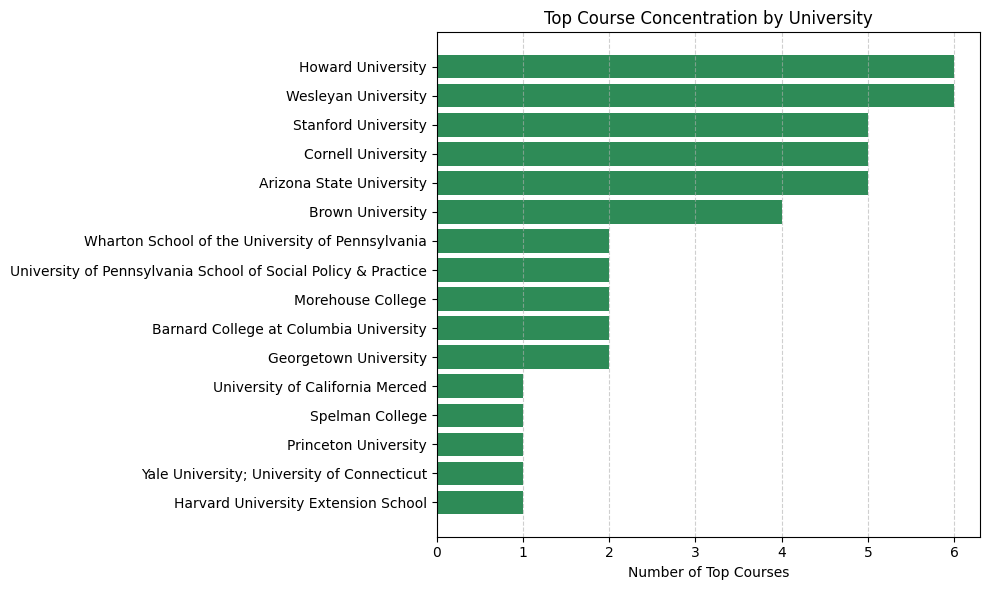

In [12]:
import matplotlib.pyplot as plt

# Step A: Get top 100 most successful courses
top100_courses = summary_sorted.head(50)

# Step B: Count university appearances
top100_concentration = top100_courses['University'].value_counts().to_frame().reset_index()
top100_concentration.columns = ['University', 'Top_100_Course_Count']

# Step C: Plotting with new color
plt.figure(figsize=(10, 6))
plt.barh(
    top100_concentration['University'],
    top100_concentration['Top_100_Course_Count'],
    color='#2E8B57'  # dark green; you can use 'gold', 'tomato', '#FF69B4', etc.
)
plt.xlabel('Number of Top Courses')
plt.title('Top Course Concentration by University')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [13]:
# STEP 1: Install Plotly if needed
!pip install plotly --quiet

import plotly.express as px
import pandas as pd

# STEP 2: Create a manual mapping of universities to states
university_state_map = {
    "Stanford University": "CA",
    "Wharton School of the University of Pennsylvania": "PA",
    "University of Pennsylvania School of Social Policy & Practice": "PA",
    "Morehouse College": "GA",
    "Cornell University": "NY",
    "Brown University": "RI",
    "Howard University": "DC",
    "Wesleyan University": "CT",
    "Arizona State University": "AZ",
    "Barnard College at Columbia University": "NY",
    "University of California Merced": "CA",
    "Georgetown University": "DC",
    "Spelman College": "GA",
    "Princeton University": "NJ",
    "Yale University; University of Connecticut": "CT",
    "Harvard University Extension School": "MA"
}

# STEP 3: Extract top 50 and map university to state
top50 = summary_sorted.head(50).copy()
top50['State'] = top50['University'].map(university_state_map)

# STEP 4: Count how many top courses each state has
state_counts = top50['State'].value_counts().reset_index()
state_counts.columns = ['State', 'Top_50_Course_Count']

# STEP 5: Plot geo heatmap
fig = px.choropleth(
    state_counts,
    locations='State',
    locationmode='USA-states',
    color='Top_50_Course_Count',
    scope='usa',
    color_continuous_scale='YlGnBu',
    title='Top 50 Course Concentration by State'
)

fig.show()


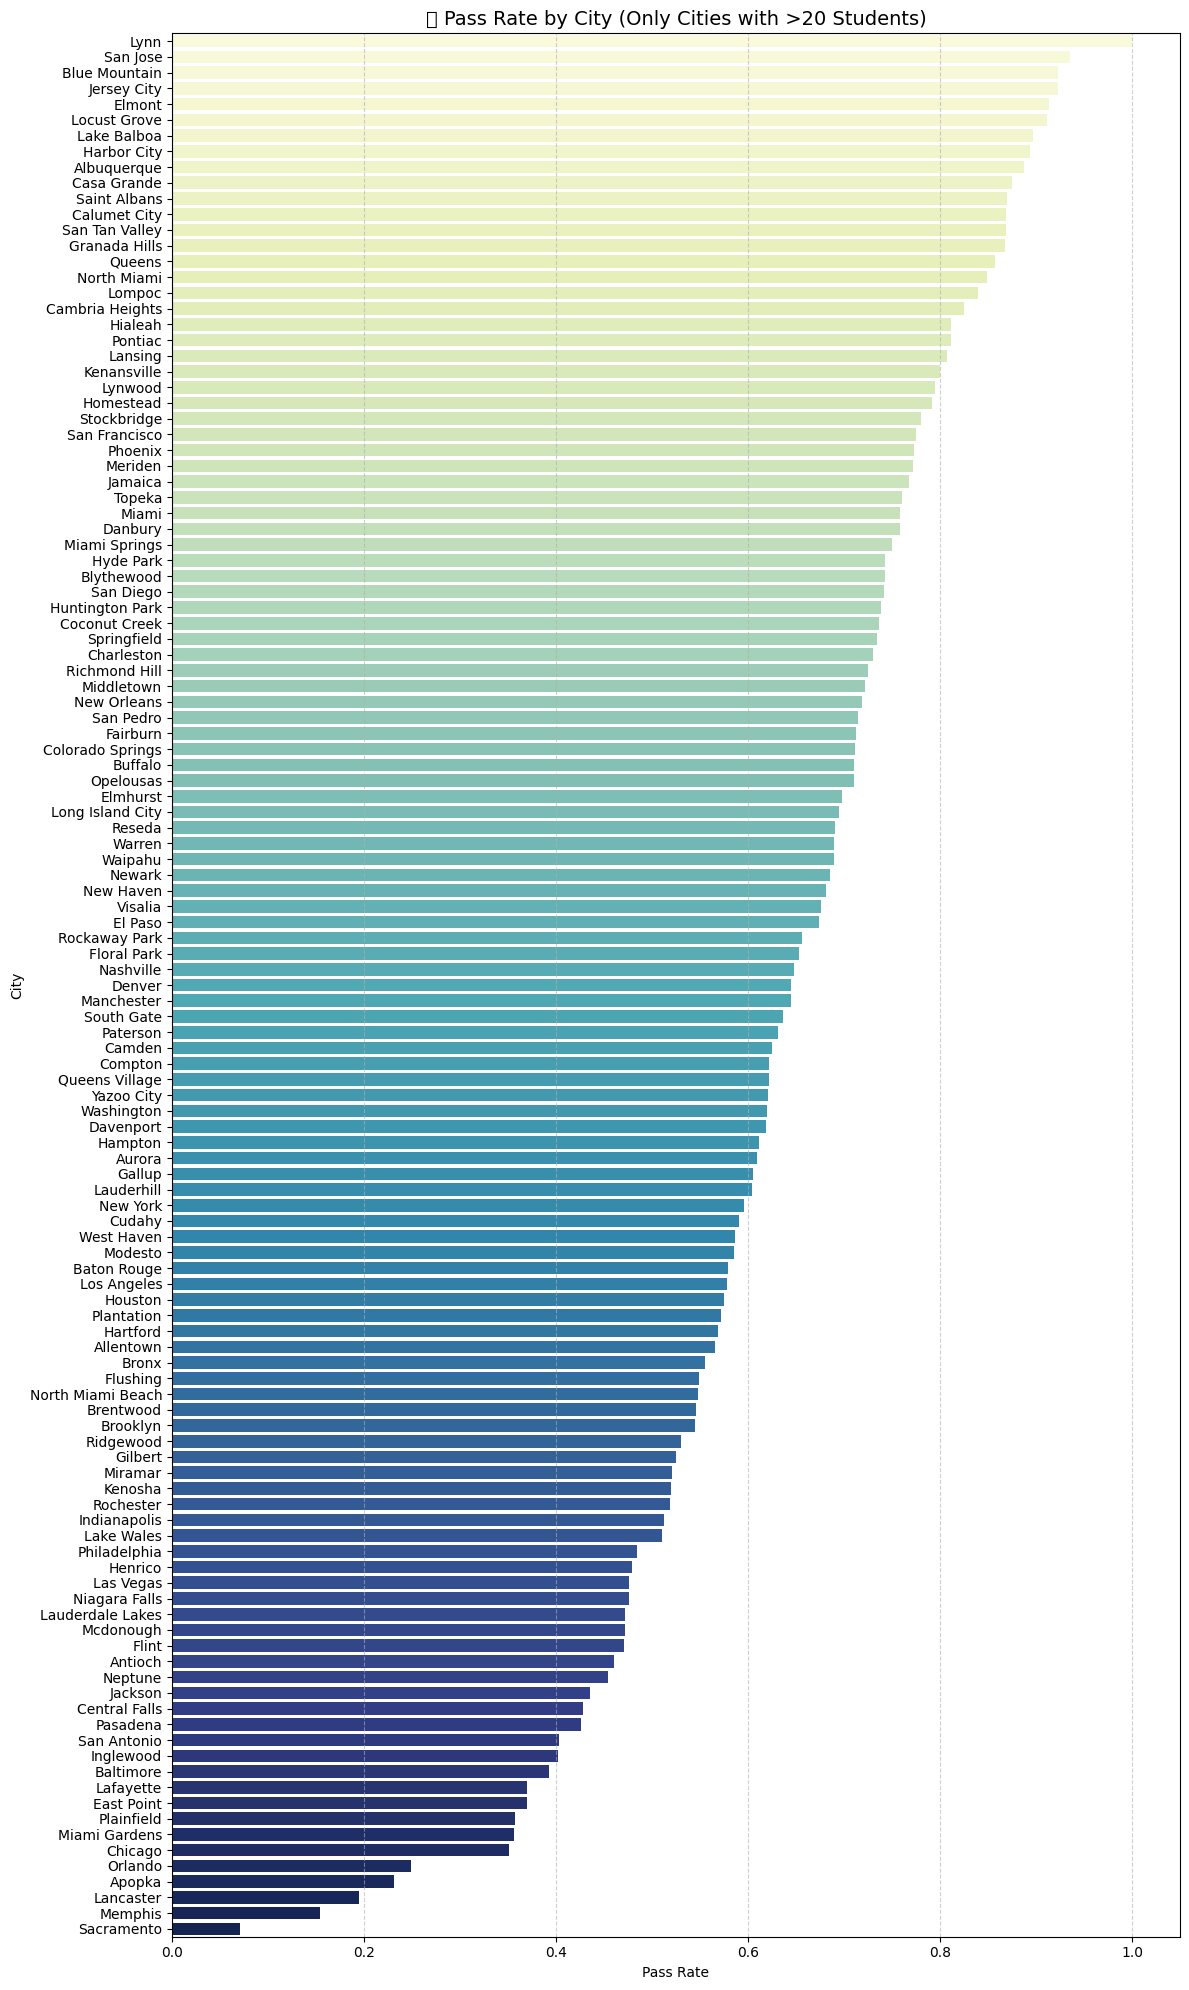

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# STEP 1: Load data
df_student = pd.read_excel('jpmcdata.xlsx', sheet_name='AdminData_Student(Seat)')
df_school = pd.read_excel('jpmcdata.xlsx', sheet_name='AdminData_High_School')

# STEP 2: Merge to include city info
student_city = pd.merge(df_student, df_school[['School Id', 'City']], on='School Id', how='left')

# STEP 3: Clean and prepare data
student_city = student_city[student_city['Pass Status'] != 'Pass_Status__c']
student_city['Passed'] = student_city['Pass Status'] == 'Passed'

# STEP 4: Group by city
city_summary = student_city.groupby('City').agg(
    pass_rate=('Passed', 'mean'),
    student_count=('Seat Id', 'count')
).reset_index()

# STEP 5: Filter out cities with fewer than 20 students
city_summary = city_summary[city_summary['student_count'] > 20]

# STEP 6: Sort for better visualization
city_summary = city_summary.sort_values(by='pass_rate', ascending=False)

# STEP 7: Plot bar chart (heatmap-like style)
plt.figure(figsize=(12, 20))
sns.barplot(data=city_summary, y='City', x='pass_rate', palette='YlGnBu')
plt.title('📍 Pass Rate by City (Only Cities with >20 Students)', fontsize=14)
plt.xlabel('Pass Rate')
plt.ylabel('City')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
